# Supply Chain Cost Analysis & Efficiency

---

## Problem Statement
Perusahaan memiliki data supply chain yang mencakup informasi produk, biaya pengiriman, biaya manufaktur, supplier, dan hasil inspeksi. Tujuan analisis ini adalah:
1. Mengidentifikasi distribusi dan tren biaya operasional (shipping & manufacturing cost)
2. Menganalisis efisiensi biaya berdasarkan supplier, lokasi, dan moda transportasi
3. Mendeteksi anomali biaya yang berpotensi merugikan perusahaan
4. Memberikan rekomendasi berbasis data untuk efisiensi biaya

---

## 1. Setup & Import Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Import & Eksplorasi Awal Data

In [5]:
# Load dataset
df = pd.read_csv('/content/supply_chain_data.csv')

print('Shape:', df.shape)
print('\nKolom:')
print(df.columns.tolist())
df.head()

Shape: (100, 24)

Kolom:
['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [6]:
# Informasi tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [7]:
# Statistik deskriptif
df.describe().round(2)

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,49.46,48.40,460.99,5776.05,47.77,15.96,49.22,5.75,5.55,17.08,567.84,14.77,47.27,2.28,529.25
std,31.17,30.74,303.78,2732.84,31.37,8.79,26.78,2.72,2.65,8.85,263.05,8.91,28.98,1.46,258.30
min,1.70,1.00,8.00,1061.62,0.00,1.00,1.00,1.00,1.01,1.00,104.00,1.00,1.09,0.02,103.92
25%,19.60,22.75,184.25,2812.85,16.75,8.00,26.00,3.75,3.54,10.00,352.00,7.00,22.98,1.01,318.78
50%,51.24,43.50,392.50,6006.35,47.50,17.00,52.00,6.00,5.32,18.00,568.50,14.00,45.91,2.14,520.43
75%,77.20,75.00,704.25,8253.98,73.00,24.00,71.25,8.00,7.60,25.00,797.00,23.00,68.62,3.56,763.08
max,99.17,100.00,996.00,9866.47,100.00,30.00,96.00,10.00,9.93,30.00,985.00,30.00,99.47,4.94,997.41


## 3. Data Cleaning

In [8]:
# Cek missing values
print('Missing Values:')
print(df.isnull().sum())

# Cek duplikat
print(f'\nJumlah duplikat: {df.duplicated().sum()}')

Missing Values:
Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

Jumlah duplikat: 0


In [9]:
# Cek outlier pada kolom biaya menggunakan Z-score
cost_cols = ['Shipping costs', 'Manufacturing costs', 'Costs']

for col in cost_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers = (z_scores > 3).sum()
    print(f'{col}: {outliers} outlier terdeteksi')

Shipping costs: 0 outlier terdeteksi
Manufacturing costs: 0 outlier terdeteksi
Costs: 0 outlier terdeteksi


In [10]:
# Rename kolom untuk konsistensi
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Kolom setelah cleaning:')
print(df.columns.tolist())

Kolom setelah cleaning:
['product_type', 'sku', 'price', 'availability', 'number_of_products_sold', 'revenue_generated', 'customer_demographics', 'stock_levels', 'lead_times', 'order_quantities', 'shipping_times', 'shipping_carriers', 'shipping_costs', 'supplier_name', 'location', 'lead_time', 'production_volumes', 'manufacturing_lead_time', 'manufacturing_costs', 'inspection_results', 'defect_rates', 'transportation_modes', 'routes', 'costs']


## 4. Exploratory Data Analysis (EDA)

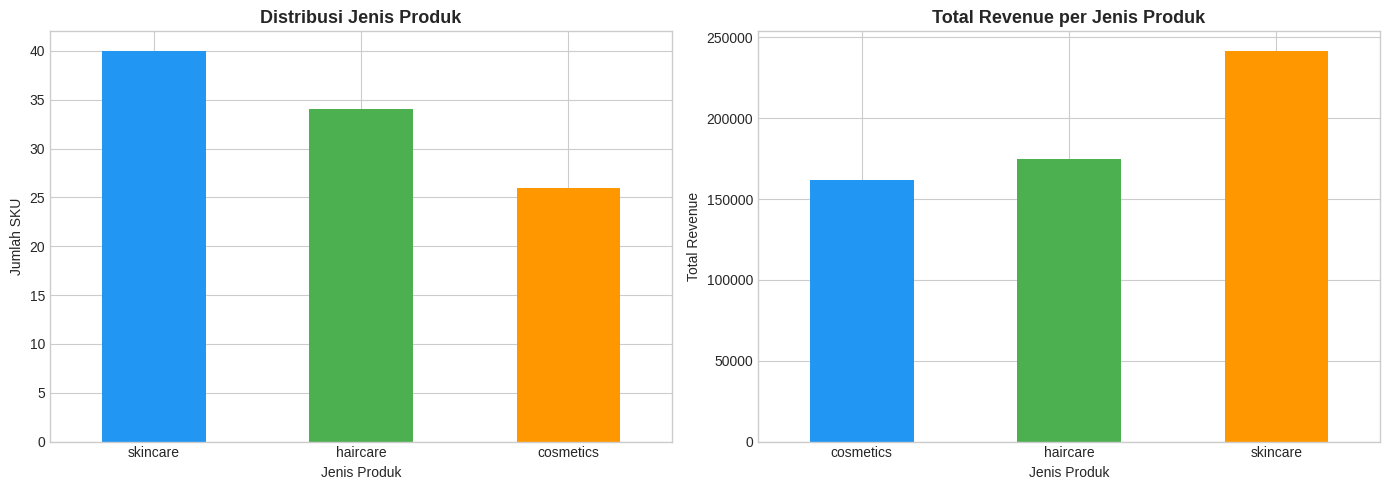

Insight: Distribusi produk dan kontribusi revenue per kategori


In [11]:
# Distribusi produk
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Product type distribution
df['product_type'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3', '#4CAF50', '#FF9800'])
axes[0].set_title('Distribusi Jenis Produk', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jenis Produk')
axes[0].set_ylabel('Jumlah SKU')
axes[0].tick_params(axis='x', rotation=0)

# Revenue per product type
df.groupby('product_type')['revenue_generated'].sum().plot(kind='bar', ax=axes[1], color=['#2196F3', '#4CAF50', '#FF9800'])
axes[1].set_title('Total Revenue per Jenis Produk', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jenis Produk')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('product_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Distribusi produk dan kontribusi revenue per kategori')

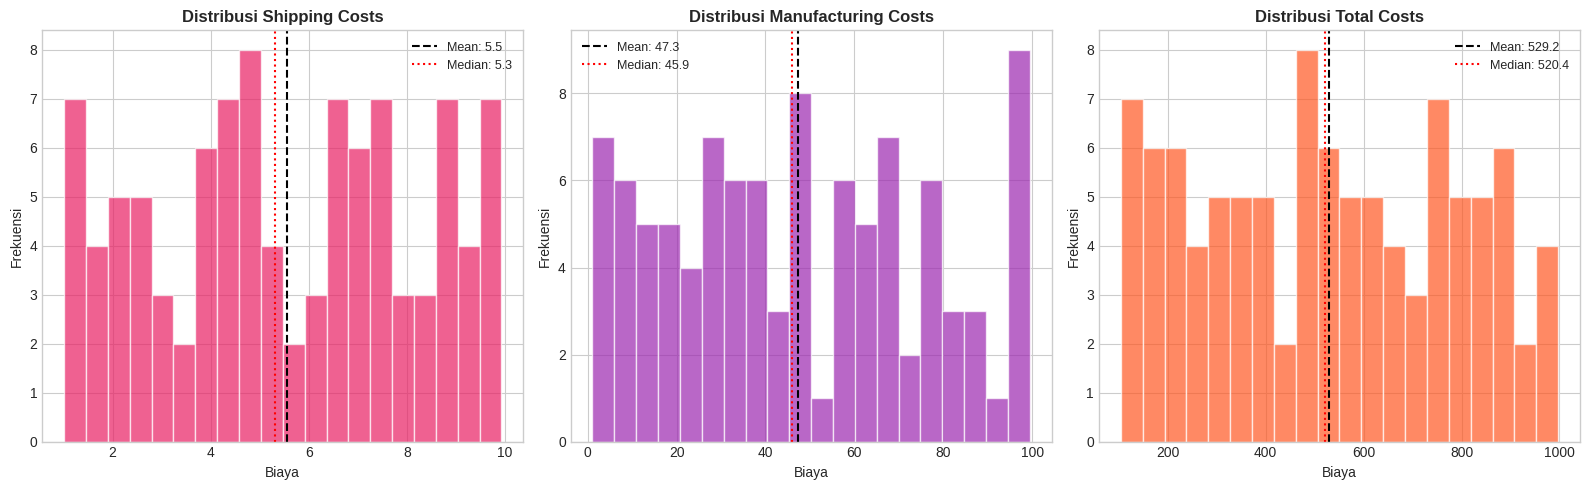

In [12]:
# Distribusi biaya operasional
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cost_cols = ['shipping_costs', 'manufacturing_costs', 'costs']
titles = ['Shipping Costs', 'Manufacturing Costs', 'Total Costs']
colors = ['#E91E63', '#9C27B0', '#FF5722']

for i, (col, title, color) in enumerate(zip(cost_cols, titles, colors)):
    axes[i].hist(df[col], bins=20, color=color, alpha=0.7, edgecolor='white')
    axes[i].axvline(df[col].mean(), color='black', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='red', linestyle=':', label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribusi {title}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Biaya')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('cost_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

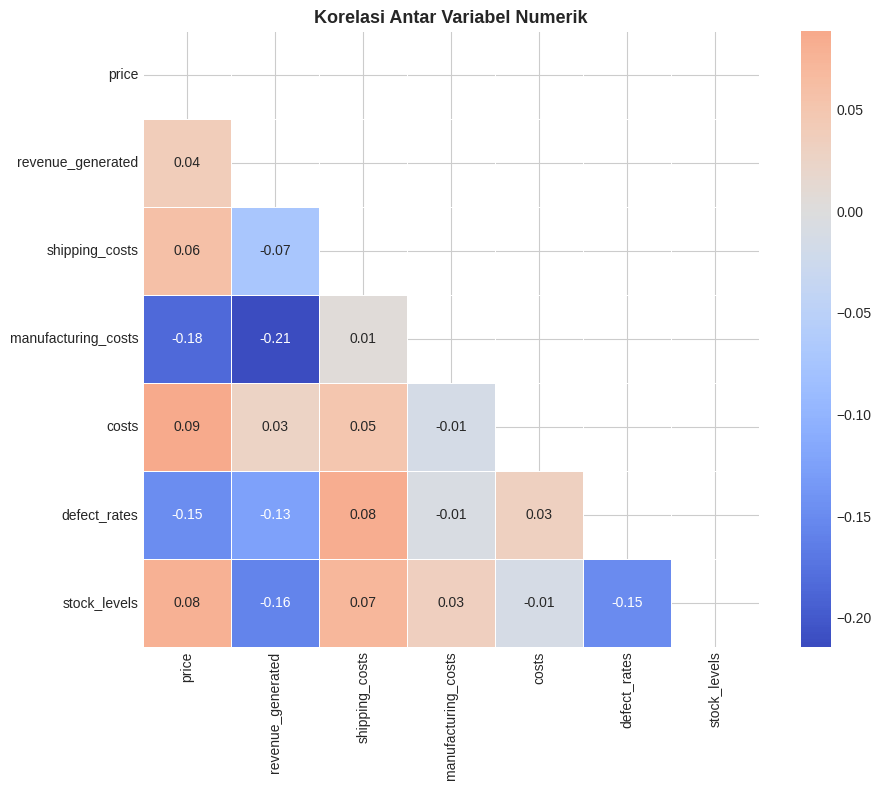

In [13]:
# Korelasi antar variabel numerik
num_cols = ['price', 'revenue_generated', 'shipping_costs', 'manufacturing_costs', 'costs', 'defect_rates', 'stock_levels']

plt.figure(figsize=(10, 8))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Korelasi Antar Variabel Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cost Analysis & Efisiensi

In [14]:
# Analisis biaya per supplier
supplier_cost = df.groupby('supplier_name').agg(
    avg_manufacturing_cost=('manufacturing_costs', 'mean'),
    avg_shipping_cost=('shipping_costs', 'mean'),
    avg_total_cost=('costs', 'mean'),
    avg_defect_rate=('defect_rates', 'mean'),
    total_revenue=('revenue_generated', 'sum')
).round(2)

# Cost efficiency ratio (revenue / total cost)
supplier_cost['cost_efficiency_ratio'] = (supplier_cost['total_revenue'] / supplier_cost['avg_total_cost']).round(2)

print('Analisis Biaya per Supplier:')
supplier_cost.sort_values('cost_efficiency_ratio', ascending=False)

Analisis Biaya per Supplier:


,avg_manufacturing_cost,avg_shipping_cost,avg_total_cost,avg_defect_rate,total_revenue,cost_efficiency_ratio
supplier_name,,,,,,
Supplier 1,45.25,5.51,574.85,1.80,157529.00,274.03
Supplier 2,41.62,5.74,515.03,2.36,125467.42,243.61
Supplier 3,43.63,4.79,468.80,2.47,97795.98,208.61
Supplier 5,44.77,5.79,536.02,2.67,110343.46,205.86
Supplier 4,62.71,5.76,521.81,2.34,86468.96,165.71


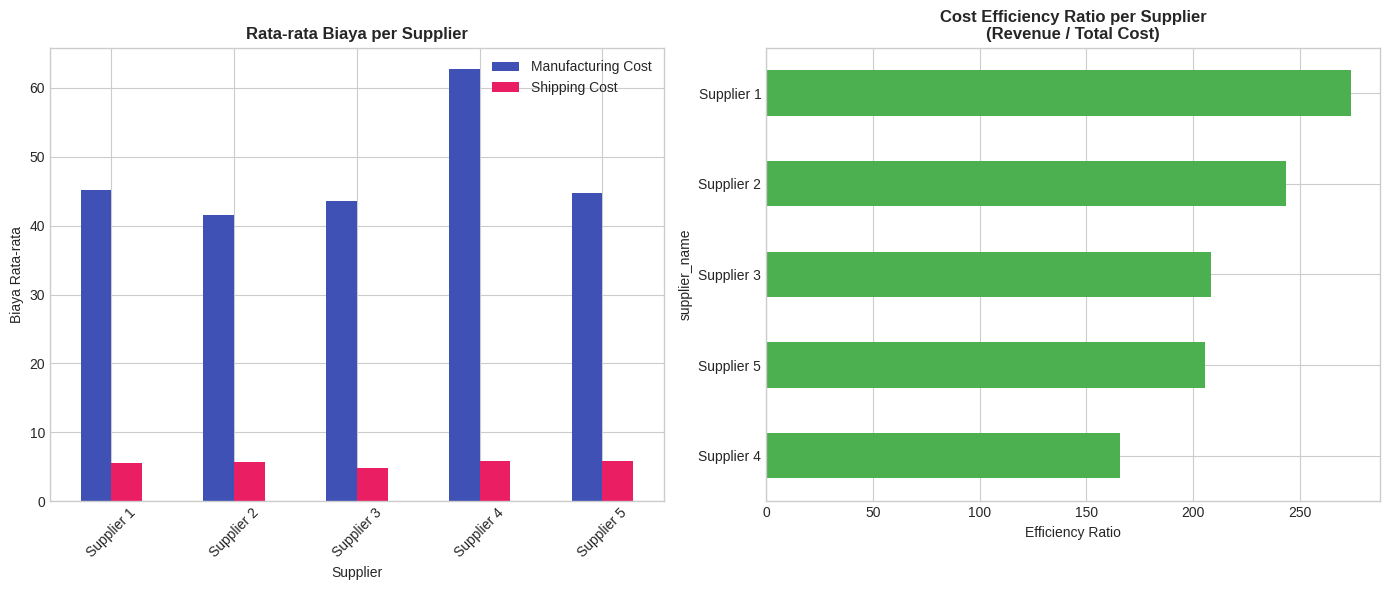

In [15]:
# Visualisasi biaya per supplier
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average cost per supplier
supplier_cost[['avg_manufacturing_cost', 'avg_shipping_cost']].plot(
    kind='bar', ax=axes[0], color=['#3F51B5', '#E91E63']
)
axes[0].set_title('Rata-rata Biaya per Supplier', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Supplier')
axes[0].set_ylabel('Biaya Rata-rata')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['Manufacturing Cost', 'Shipping Cost'])

# Cost efficiency ratio
supplier_cost['cost_efficiency_ratio'].sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='#4CAF50'
)
axes[1].set_title('Cost Efficiency Ratio per Supplier\n(Revenue / Total Cost)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Efficiency Ratio')

plt.tight_layout()
plt.savefig('supplier_cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Analisis biaya per moda transportasi
transport_cost = df.groupby('transportation_modes').agg(
    avg_shipping_cost=('shipping_costs', 'mean'),
    avg_shipping_time=('shipping_times', 'mean'),
    total_orders=('order_quantities', 'sum')
).round(2)

print('Analisis Biaya per Moda Transportasi:')
transport_cost

Analisis Biaya per Moda Transportasi:


,avg_shipping_cost,avg_shipping_time,total_orders
transportation_modes,,,
Air,6.02,5.12,1341
Rail,5.47,6.57,1342
Road,5.54,4.72,1386
Sea,4.97,7.12,853


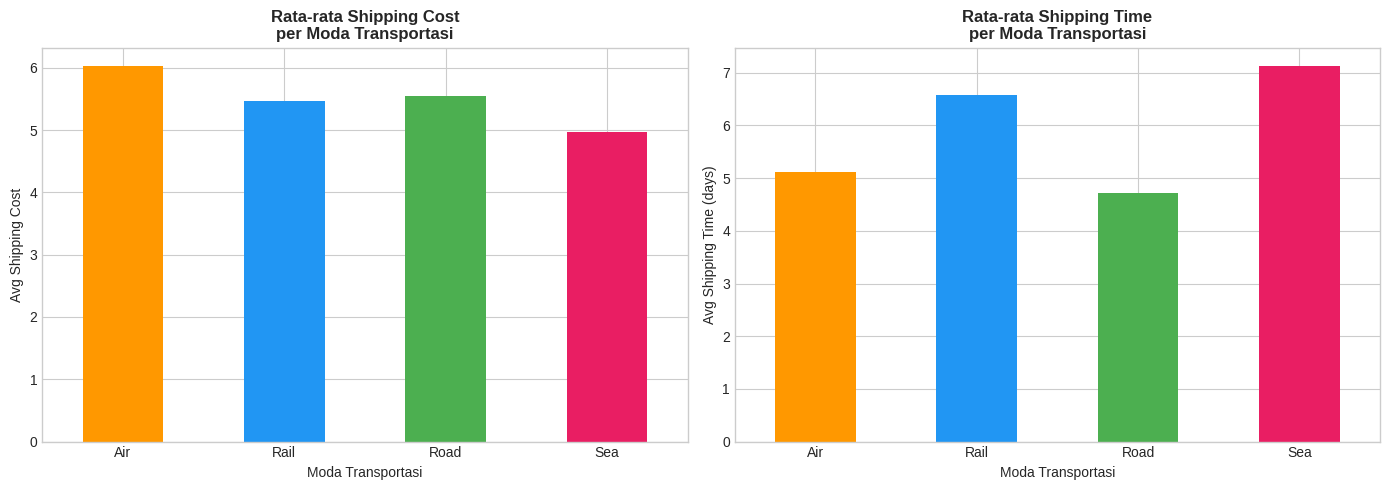

In [17]:
# Visualisasi transportasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

transport_cost['avg_shipping_cost'].plot(kind='bar', ax=axes[0], color=['#FF9800', '#2196F3', '#4CAF50', '#E91E63'])
axes[0].set_title('Rata-rata Shipping Cost\nper Moda Transportasi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Moda Transportasi')
axes[0].set_ylabel('Avg Shipping Cost')
axes[0].tick_params(axis='x', rotation=0)

transport_cost['avg_shipping_time'].plot(kind='bar', ax=axes[1], color=['#FF9800', '#2196F3', '#4CAF50', '#E91E63'])
axes[1].set_title('Rata-rata Shipping Time\nper Moda Transportasi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Moda Transportasi')
axes[1].set_ylabel('Avg Shipping Time (days)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('transport_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Analisis biaya per lokasi
location_cost = df.groupby('location').agg(
    avg_total_cost=('costs', 'mean'),
    avg_manufacturing_cost=('manufacturing_costs', 'mean'),
    total_revenue=('revenue_generated', 'sum'),
    avg_defect_rate=('defect_rates', 'mean')
).round(2)

print('Analisis Biaya per Lokasi:')
location_cost.sort_values('avg_total_cost', ascending=False)

Analisis Biaya per Lokasi:


,avg_total_cost,avg_manufacturing_cost,total_revenue,avg_defect_rate
location,,,,
Chennai,621.75,51.15,119142.82,2.64
Bangalore,586.71,61.99,102601.72,2.09
Delhi,548.24,48.88,81027.70,2.23
Kolkata,491.27,41.86,137077.55,2.29
Mumbai,428.34,36.73,137755.03,2.12


## 6. Anomali Detection

In [19]:
# Deteksi anomali biaya menggunakan IQR method
def detect_anomaly_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

print('=== ANOMALI TERDETEKSI ===')
for col in ['shipping_costs', 'manufacturing_costs', 'costs']:
    anomalies = detect_anomaly_iqr(df, col)
    print(f'\n{col}: {len(anomalies)} anomali')
    if len(anomalies) > 0:
        print(anomalies[['sku', 'product_type', 'supplier_name', col]].to_string())

=== ANOMALI TERDETEKSI ===

shipping_costs: 0 anomali

manufacturing_costs: 0 anomali

costs: 0 anomali


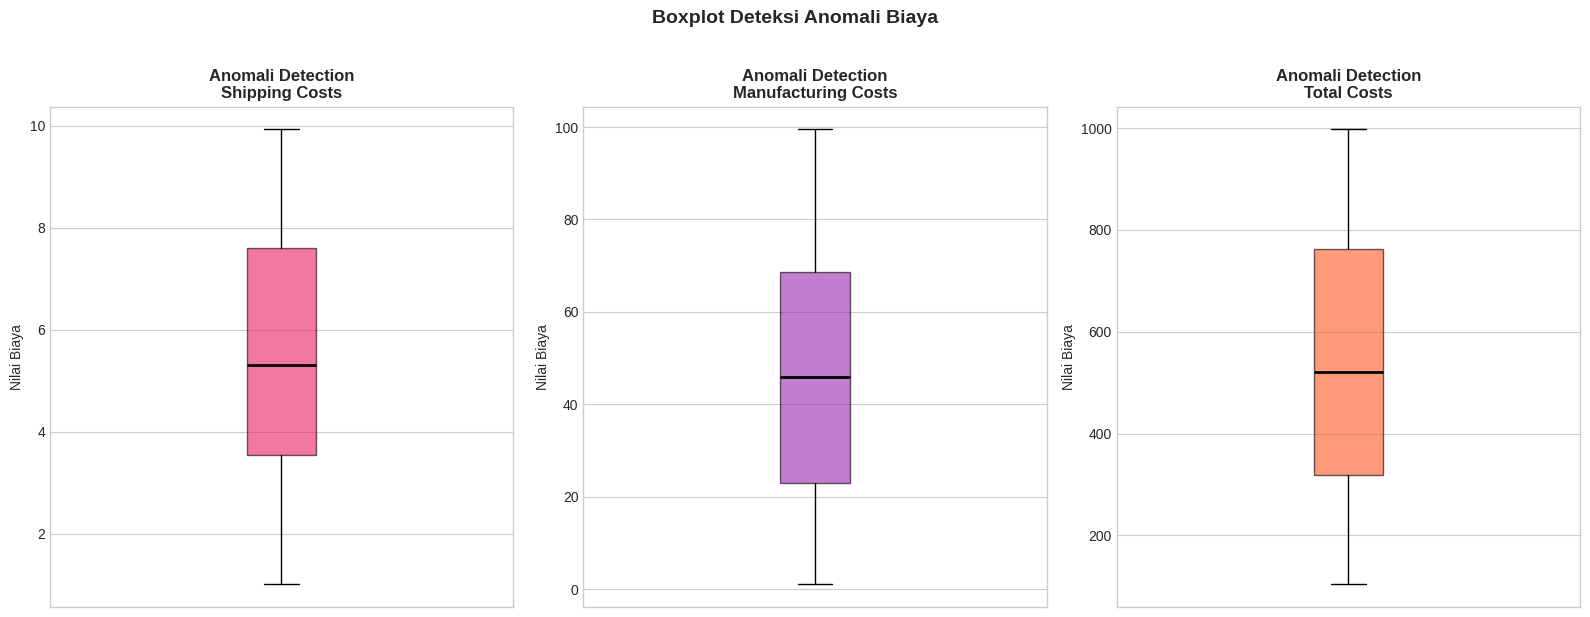

In [20]:
# Visualisasi anomali dengan boxplot
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

cost_cols = ['shipping_costs', 'manufacturing_costs', 'costs']
titles = ['Shipping Costs', 'Manufacturing Costs', 'Total Costs']
colors = ['#E91E63', '#9C27B0', '#FF5722']

for i, (col, title, color) in enumerate(zip(cost_cols, titles, colors)):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(f'Anomali Detection\n{title}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nilai Biaya')
    axes[i].set_xticks([])

plt.suptitle('Boxplot Deteksi Anomali Biaya', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

Produk dengan defect rate tinggi: 25

Rata-rata biaya produk defect tinggi vs normal:
Manufacturing cost (high defect): 47.03
Manufacturing cost (normal): 47.35


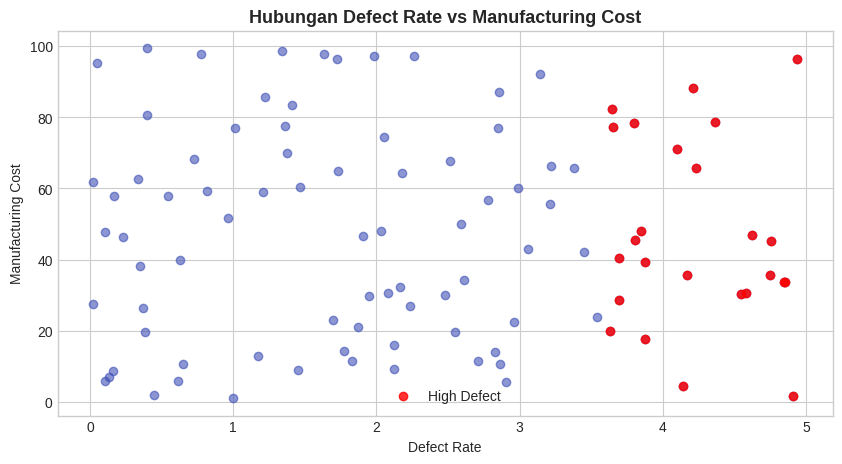

In [21]:
# Analisis produk dengan defect rate tinggi & dampak biaya
high_defect = df[df['defect_rates'] > df['defect_rates'].quantile(0.75)]

print(f'Produk dengan defect rate tinggi: {len(high_defect)}')
print(f'\nRata-rata biaya produk defect tinggi vs normal:')
print(f"Manufacturing cost (high defect): {high_defect['manufacturing_costs'].mean():.2f}")
print(f"Manufacturing cost (normal): {df[df['defect_rates'] <= df['defect_rates'].quantile(0.75)]['manufacturing_costs'].mean():.2f}")

# Visualisasi
plt.figure(figsize=(10, 5))
plt.scatter(df['defect_rates'], df['manufacturing_costs'], alpha=0.6, color='#3F51B5')
plt.scatter(high_defect['defect_rates'], high_defect['manufacturing_costs'],
            color='red', alpha=0.8, label='High Defect', zorder=5)
plt.xlabel('Defect Rate')
plt.ylabel('Manufacturing Cost')
plt.title('Hubungan Defect Rate vs Manufacturing Cost', fontsize=13, fontweight='bold')
plt.legend()
plt.savefig('defect_cost_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Ringkasan Insight & Rekomendasi

In [22]:
# Summary statistics
print('='*55)
print('       RINGKASAN ANALISIS SUPPLY CHAIN COST')
print('='*55)

print(f"""
OVERVIEW DATA:
- Total SKU dianalisis     : {len(df)}
- Total Revenue            : Rp {df['revenue_generated'].sum():,.0f}
- Total Shipping Cost      : Rp {df['shipping_costs'].sum():,.0f}
- Total Manufacturing Cost : Rp {df['manufacturing_costs'].sum():,.0f}
- Total Operational Cost   : Rp {df['costs'].sum():,.0f}

COST EFFICIENCY:
- Supplier paling efisien  : {supplier_cost['cost_efficiency_ratio'].idxmax()}
- Supplier kurang efisien  : {supplier_cost['cost_efficiency_ratio'].idxmin()}
- Transportasi termurah    : {transport_cost['avg_shipping_cost'].idxmin()}
- Transportasi termahal    : {transport_cost['avg_shipping_cost'].idxmax()}

ANOMALI:
- SKU dengan total cost anomali terdeteksi menggunakan IQR
- Produk dengan defect rate tinggi cenderung memiliki
  manufacturing cost yang lebih tinggi
""")

print('='*55)
print('REKOMENDASI:')
print('='*55)
print("""
1. OPTIMASI SUPPLIER
   Prioritaskan supplier dengan cost efficiency ratio tertinggi.
   Evaluasi ulang kontrak supplier dengan rasio rendah.

2. EFISIENSI TRANSPORTASI
   Pertimbangkan moda transportasi dengan biaya rendah
   untuk pengiriman non-urgent guna menekan shipping cost.

3. QUALITY CONTROL
   Tingkatkan inspeksi pada produk dengan defect rate tinggi
   untuk mengurangi manufacturing cost yang tidak efisien.

4. MONITORING ANOMALI
   Implementasikan dashboard monitoring real-time untuk
   mendeteksi lonjakan biaya lebih awal.
""")

       RINGKASAN ANALISIS SUPPLY CHAIN COST

OVERVIEW DATA:
- Total SKU dianalisis     : 100
- Total Revenue            : Rp 577,605
- Total Shipping Cost      : Rp 555
- Total Manufacturing Cost : Rp 4,727
- Total Operational Cost   : Rp 52,925

COST EFFICIENCY:
- Supplier paling efisien  : Supplier 1
- Supplier kurang efisien  : Supplier 4
- Transportasi termurah    : Sea
- Transportasi termahal    : Air

ANOMALI:
- SKU dengan total cost anomali terdeteksi menggunakan IQR
- Produk dengan defect rate tinggi cenderung memiliki
  manufacturing cost yang lebih tinggi

REKOMENDASI:

1. OPTIMASI SUPPLIER
   Prioritaskan supplier dengan cost efficiency ratio tertinggi.
   Evaluasi ulang kontrak supplier dengan rasio rendah.

2. EFISIENSI TRANSPORTASI
   Pertimbangkan moda transportasi dengan biaya rendah
   untuk pengiriman non-urgent guna menekan shipping cost.

3. QUALITY CONTROL
   Tingkatkan inspeksi pada produk dengan defect rate tinggi
   untuk mengurangi manufacturing cost yang tidak


Dataset: Supply Chain Dataset (Kaggle)  
Tools: Python, Pandas, Matplotlib, Seaborn, NumPy